In [6]:
import numpy as np
import pandas as pd
from quant_utils import midterm_entry_signal_backtrack
import matplotlib.pyplot as plt
import akshare as ak
from tqdm import tqdm
from datetime import datetime, timedelta
from collections import Counter

In [7]:

def equity_curve_single_stock(df, entry_func):
    df = df.copy().reset_index(drop=True)
    df["日期"] = pd.to_datetime(df["日期"])
    df["MA20"] = df["收盘"].rolling(20).mean()
    df["MA60"] = df["收盘"].rolling(60).mean()

    cash = 1.0          # 初始资金 = 1（你也可以改成 100000）
    shares = 0.0        # 持仓股数
    in_pos = False

    entry_price = None
    entry_date = None

    curve = []          # 每天的资金（equity）
    trades = []         # 每笔交易

    for i in range(70, len(df)):
        date = df.loc[i, "日期"]
        close = df.loc[i, "收盘"]
        ma20  = df.loc[i, "MA20"]

        # 1) 先记录当天资金（持仓就按市值算）
        if in_pos and np.isfinite(close) and close > 0:
            equity_today = shares * close
        else:
            equity_today = cash

        curve.append({"date": date, "equity": float(equity_today)})

        # 2) 如果空仓：检查是否要买入
        if not in_pos:
            if entry_func(df, i):
                if np.isfinite(close) and close > 0:
                    shares = cash / close     # 全仓买入：把现金换成股票
                    in_pos = True
                    entry_price = close
                    entry_date = date
            continue

        # 3) 如果持仓：检查是否要卖出（跌破 MA20）
        if in_pos:
            if np.isfinite(ma20) and np.isfinite(close) and close < ma20:
                exit_price = close
                exit_date = date

                # 全仓卖出：把股票换回现金
                cash = shares * exit_price
                ret = (exit_price - entry_price) / entry_price

                trades.append({
                    "entry_date": entry_date,
                    "exit_date": exit_date,
                    "entry_price": float(entry_price),
                    "exit_price": float(exit_price),
                    "ret": float(ret)
                })

                shares = 0.0
                in_pos = False
                entry_price = None
                entry_date = None

    return pd.DataFrame(curve), pd.DataFrame(trades)


交易次数: 23
平均单笔收益: 0.060621749690965517
胜率: 0.43478260869565216
最终资金倍数: 3.016669191738255
最大回撤: -0.42436431591465695


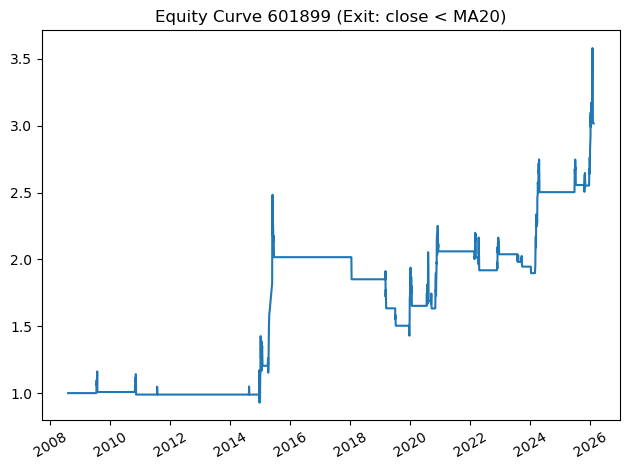

In [10]:

def max_drawdown(equity_series):
    s = equity_series.values.astype(float)
    peak = np.maximum.accumulate(s)
    dd = (s / peak) - 1
    return float(dd.min())

code = "601899"  # 例子：平安银行
df = ak.stock_zh_a_hist(symbol=code, period="daily", adjust="qfq")

curve_df, trades_df = equity_curve_single_stock(df, midterm_entry_signal_backtrack)

print("交易次数:", len(trades_df))
if len(trades_df) > 0:
    print("平均单笔收益:", trades_df["ret"].mean())
    print("胜率:", (trades_df["ret"] > 0).mean())

print("最终资金倍数:", curve_df["equity"].iloc[-1])
print("最大回撤:", max_drawdown(curve_df["equity"]))

plt.figure()
plt.plot(curve_df["date"], curve_df["equity"])
plt.title(f"Equity Curve {code} (Exit: close < MA20)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [20]:
stock_list = ak.stock_info_a_code_name()

#测试版
stock_list = stock_list.head(10)

stock_list

,code,name
0,000001,平安银行
1,000002,万 科Ａ
2,000004,*ST国华
3,000006,深振业Ａ
4,000007,全新好
5,000008,神州高铁
6,000009,中国宝安
7,000010,美丽生态
8,000011,深物业A
9,000012,南 玻Ａ


In [29]:

def generate_trades_for_stock(df, code):
    df = df.copy().reset_index(drop=True)
    df["日期"] = pd.to_datetime(df["日期"])
    df["MA20"] = df["收盘"].rolling(20).mean()
    df["MA60"] = df["收盘"].rolling(60).mean()

    trades = []

    for i in range(70, len(df)-1):

        if not midterm_entry_signal_backtrack(df, i):
            continue

        entry_price = df.loc[i, "收盘"]
        if not np.isfinite(entry_price) or entry_price <= 0:
            continue

        # 卖出：跌破 MA20
        for j in range(i+1, len(df)):
            if df.loc[j, "收盘"] < df.loc[j, "MA20"]:
                exit_price = df.loc[j, "收盘"]
                if not np.isfinite(exit_price) or exit_price <= 0:
                    break

                ret = (exit_price - entry_price) / entry_price

                trades.append({
                    "code": code,
                    "entry_date": df.loc[i, "日期"],
                    "exit_date": df.loc[j, "日期"],
                    "ret": ret
                })
                break

    return trades


In [ ]:
stock_list = ak.stock_info_a_code_name().head(100)

all_trades = []

for _, row in tqdm(stock_list.iterrows(), total=len(stock_list)):
    code = row["code"]
    try:
        df = ak.stock_zh_a_hist(symbol=code, period="daily", adjust="qfq")
        if df is None or len(df) < 200:
            continue

        trades = generate_trades_for_stock(df, code)
        all_trades.extend(trades)

    except:
        continue

trades_df = pd.DataFrame(all_trades)

trades_df
trades_df = trades_df.sort_values("entry_date").reset_index(drop=True)

print("总交易信号:", len(trades_df))


100%|██████████| 100/100 [05:37<00:00,  3.37s/it]

总交易信号: 5530


In [32]:
trades_df = trades_df.sort_values("entry_date").reset_index(drop=True)
trades_df.head()



,code,entry_date,exit_date,ret
0,000009,1991-10-23,1991-11-26,1.848485
1,000009,1991-10-24,1991-11-26,1.764706
2,000004,1991-10-24,1991-11-25,0.498516
3,000009,1991-10-25,1991-11-26,1.685714
4,000004,1991-10-26,1991-11-25,0.489676


In [36]:

all_trades

[{'code': '000001',
  'entry_date': Timestamp('1997-04-03 00:00:00'),
  'exit_date': Timestamp('1997-05-16 00:00:00'),
  'ret': np.float64(2.333333333333333)},
 {'code': '000001',
  'entry_date': Timestamp('1997-04-04 00:00:00'),
  'exit_date': Timestamp('1997-05-16 00:00:00'),
  'ret': np.float64(1.615384615384615)},
 {'code': '000001',
  'entry_date': Timestamp('1997-04-07 00:00:00'),
  'exit_date': Timestamp('1997-05-16 00:00:00'),
  'ret': np.float64(1.3943661971830987)},
 {'code': '000001',
  'entry_date': Timestamp('1997-04-09 00:00:00'),
  'exit_date': Timestamp('1997-05-16 00:00:00'),
  'ret': np.float64(1.8333333333333335)},
 {'code': '000001',
  'entry_date': Timestamp('1997-04-15 00:00:00'),
  'exit_date': Timestamp('1997-05-16 00:00:00'),
  'ret': np.float64(2.2075471698113205)},
 {'code': '000001',
  'entry_date': Timestamp('1997-10-31 00:00:00'),
  'exit_date': Timestamp('1997-11-11 00:00:00'),
  'ret': np.float64(0.011173184357541908)},
 {'code': '000001',
  'entry_date'

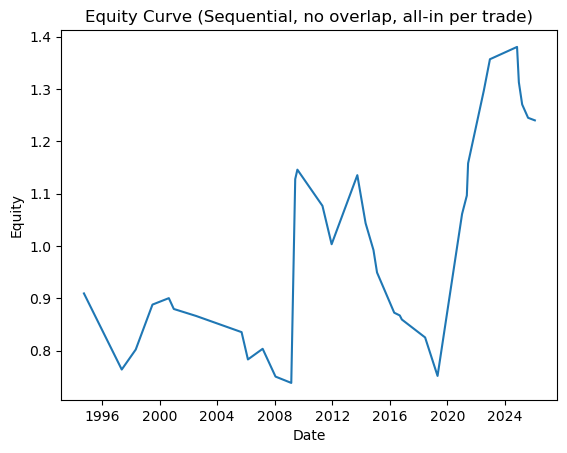

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# trades = 你这个 list[dict]
trades_df = pd.DataFrame(trades).copy()
trades_df["entry_date"] = pd.to_datetime(trades_df["entry_date"])
trades_df["exit_date"]  = pd.to_datetime(trades_df["exit_date"])
trades_df = trades_df.sort_values(["entry_date", "exit_date"]).reset_index(drop=True)

# 只保留合理收益（避免 ret=2.33 这种是 +233% 也可以保留；这里只过滤极端异常）
trades_df = trades_df[np.isfinite(trades_df["ret"])].copy()

equity = 1.0
equity_points = []
last_exit = pd.Timestamp.min

for _, tr in trades_df.iterrows():
    # 如果这笔交易和上一笔有重叠，就跳过（因为全仓策略无法同时持有）
    if tr["entry_date"] < last_exit:
        continue

    equity *= (1 + float(tr["ret"]))
    equity_points.append({"date": tr["exit_date"], "equity": equity})
    last_exit = tr["exit_date"]

curve_df = pd.DataFrame(equity_points).sort_values("date")

plt.figure()
plt.plot(curve_df["date"], curve_df["equity"])
plt.title("Equity Curve (Sequential, no overlap, all-in per trade)")
plt.xlabel("Date"); plt.ylabel("Equity")
plt.show()


In [40]:
equity_points

[{'date': Timestamp('1994-09-30 00:00:00'), 'equity': 0.9090909090909092},
 {'date': Timestamp('1997-05-16 00:00:00'), 'equity': 0.7636363636363637},
 {'date': Timestamp('1998-05-06 00:00:00'), 'equity': 0.8018181818181819},
 {'date': Timestamp('1999-07-05 00:00:00'), 'equity': 0.8877272727272727},
 {'date': Timestamp('2000-08-23 00:00:00'), 'equity': 0.9000568181818182},
 {'date': Timestamp('2000-12-27 00:00:00'), 'equity': 0.8793658568443051},
 {'date': Timestamp('2002-07-15 00:00:00'), 'equity': 0.8660421317406035},
 {'date': Timestamp('2005-09-12 00:00:00'), 'equity': 0.8351120556070105},
 {'date': Timestamp('2006-02-20 00:00:00'), 'equity': 0.7829175521315723},
 {'date': Timestamp('2007-03-01 00:00:00'), 'equity': 0.8032530729661587},
 {'date': Timestamp('2008-01-21 00:00:00'), 'equity': 0.7501454317783135},
 {'date': Timestamp('2009-02-24 00:00:00'), 'equity': 0.7380463119109214},
 {'date': Timestamp('2009-06-04 00:00:00'), 'equity': 1.1275707543083524},
 {'date': Timestamp('2009